In [1]:
import numpy as np
import pandas as pd
import os, sys, glob
%load_ext autoreload
%autoreload 2
import camcan_utils as utils
import nibabel as nib
from config import *
from nibabel import Nifti1Image
from scipy import stats
from nilearn.maskers import NiftiMasker, NiftiLabelsMasker
import matplotlib.pyplot as plt
import scprep, tphate, phate
from nilearn import plotting
import shutil
import seaborn as sns
from brainiak.searchlight.searchlight import Searchlight
from camcan_utils import get_brain_cmap
import skdim
import ide_helpers as ide

/gpfs/milgram/project/casey/elb77/conda_envs/env_tda/lib/python3.7/site-packages/nilearn/__init__.py:69: FutureWarning: Python 3.7 support is deprecated and will be removed in release 0.12 of Nilearn. Consider switching to Python 3.9 or 3.10.
  _python_deprecation_warnings()


In [2]:
subs = utils.get_intersecting_subjects(35)
# sub = subs[0]
# task='SMT'
# metric='ISC'
# a = utils.get_metric_nii_subject(sub, task, metric, filter_by_age=35)

In [15]:
mask = utils.get_intersect_mask(35)
cmap = utils.get_brain_cmap()
# aggregate results
coords = np.where(mask.get_fdata() == 1)
# start with ISC
for t in ['rest','movie','SMT']:
    fns = sorted(glob.glob(f'{CAMCAN_RESULTS_DIR}/ISC/LOSO/*filter_35_{t}*ISC*.nii.gz'))
    print(f'found {len(fns)} for {t} ISC')
    
    # plot the group average
    temp = np.zeros(mask.shape)
    results_vecs = []
    for i, f in enumerate(fns):
        d = nib.load(f).get_fdata()
        temp = np.add(temp, d)
        vec = d[coords[0][:], coords[1][:], coords[2][:]]
        results_vecs.append(vec)
    temp /= len(fns)
    r = np.array(results_vecs)
    print(r.shape)
    np.save(f'{CAMCAN_RESULTS_DIR}/ISC/{t.upper()}_ISC_all_subjects_results.npy', r)
    
    
    n = Nifti1Image(temp, affine=mask.affine)
    nib.save(n, f'{CAMCAN_RESULTS_DIR}/ISC/group_average_{t}_ISC_whole_brain_SL_rad5.nii.gz')
    plot_fn = f'CamCAN/plots/group_average_{t}_ISC_whole_brain_SL_rad5.png'
    plotting.plot_img_on_surf(n, 
                              views=['lateral','medial'], 
                              cmap=cmap, 
                              inflate=True, 
                              bg_on_data=False, 
                                      alpha=0.8,
                              output_file=plot_fn,
                              darkness=0.8, 
                              threshold=0.1,
                              vmax=0.4, title=f'Camcan {t} ISC',
                             )
    plt.close()
    print(plot_fn)
    

found 117 for rest ISC
(117, 86741)
CamCAN/plots/group_average_rest_ISC_whole_brain_SL_rad5.png
found 117 for movie ISC
(117, 86741)
CamCAN/plots/group_average_movie_ISC_whole_brain_SL_rad5.png
found 117 for SMT ISC
(117, 86741)
CamCAN/plots/group_average_SMT_ISC_whole_brain_SL_rad5.png


In [17]:
movie_isc = np.load(f'{CAMCAN_RESULTS_DIR}/ISC/MOVIE_ISC_all_subjects_results.npy')
smt_isc = np.load(f'{CAMCAN_RESULTS_DIR}/ISC/SMT_ISC_all_subjects_results.npy')
rest_isc = np.load(f'{CAMCAN_RESULTS_DIR}/ISC/REST_ISC_all_subjects_results.npy')

movie_optt = np.load(f'{CAMCAN_RESULTS_DIR}/aggregated_npy/MOVIE_tphate_optt_all_subjects_results.npy')
smt_optt = np.load(f'{CAMCAN_RESULTS_DIR}/aggregated_npy/SMT_tphate_optt_all_subjects_results.npy')
rest_optt = np.load(f'{CAMCAN_RESULTS_DIR}/aggregated_npy/REST_tphate_optt_all_subjects_results.npy')


In [18]:
list2['movie_dim']

array([3.1312225 , 3.13322157, 3.1338396 , ..., 3.14982116, 3.17503261,
       3.20447957])

In [22]:
movie_optt.max()

41.0

In [27]:
stats.pearsonr(list1['movie_ISC'] , list2['SMT_dim'])

(0.28831774632330875, 0.0)

In [32]:
df1 = pd.DataFrame(columns=['metric','score','task','subject'])
temp = pd.DataFrame({'metric':np.repeat('optt',117), 
                     'score':np.mean(movie_optt,axis=1), 
                   'task':np.repeat('movie',117),
                   'subject':np.arange(117)})
temp1 = pd.DataFrame({'metric':np.repeat('optt',117), 
                     'score':np.mean(smt_optt,axis=1), 
                   'task':np.repeat('SMT',117),
                   'subject':np.arange(117)})
temp2 = pd.DataFrame({'metric':np.repeat('optt',117), 
                     'score':np.mean(rest_optt,axis=1), 
                   'task':np.repeat('Rest',117),
                   'subject':np.arange(117)})
df1=pd.concat([df1, temp, temp1, temp2])


<AxesSubplot:xlabel='task', ylabel='score'>

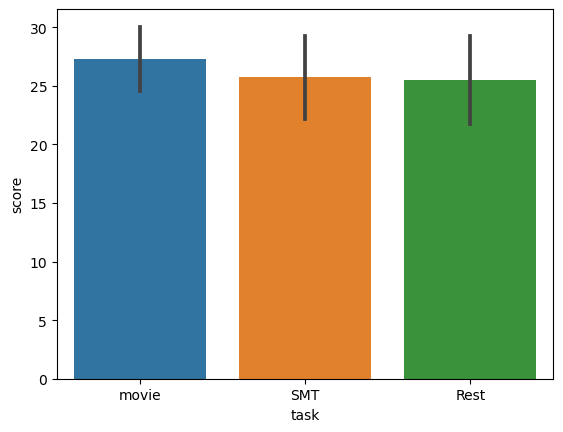

In [34]:
sns.barplot(data=df1, x='task', y='score', ci='sd')

In [ ]:
#list1={'movie_ISC':np.mean(movie_isc,axis=1), 'SMT_ISC':np.mean(smt_isc,axis=1),'rest_ISC':np.mean(rest_isc,axis=1)}
list2 = pd.DataFrame({'movie_dim':np.mean(movie_optt,axis=1),'SMT_dim':np.mean(smt_optt,axis=1),'rest_dim':np.mean(rest_optt,axis=1)}

[('movie_ISC', 'movie_dim'), ('movie_ISC', 'SMT_dim'), ('movie_ISC', 'rest_dim'), ('SMT_ISC', 'movie_dim'), ('SMT_ISC', 'SMT_dim'), ('SMT_ISC', 'rest_dim'), ('rest_ISC', 'movie_dim'), ('rest_ISC', 'SMT_dim'), ('rest_ISC', 'rest_dim')]


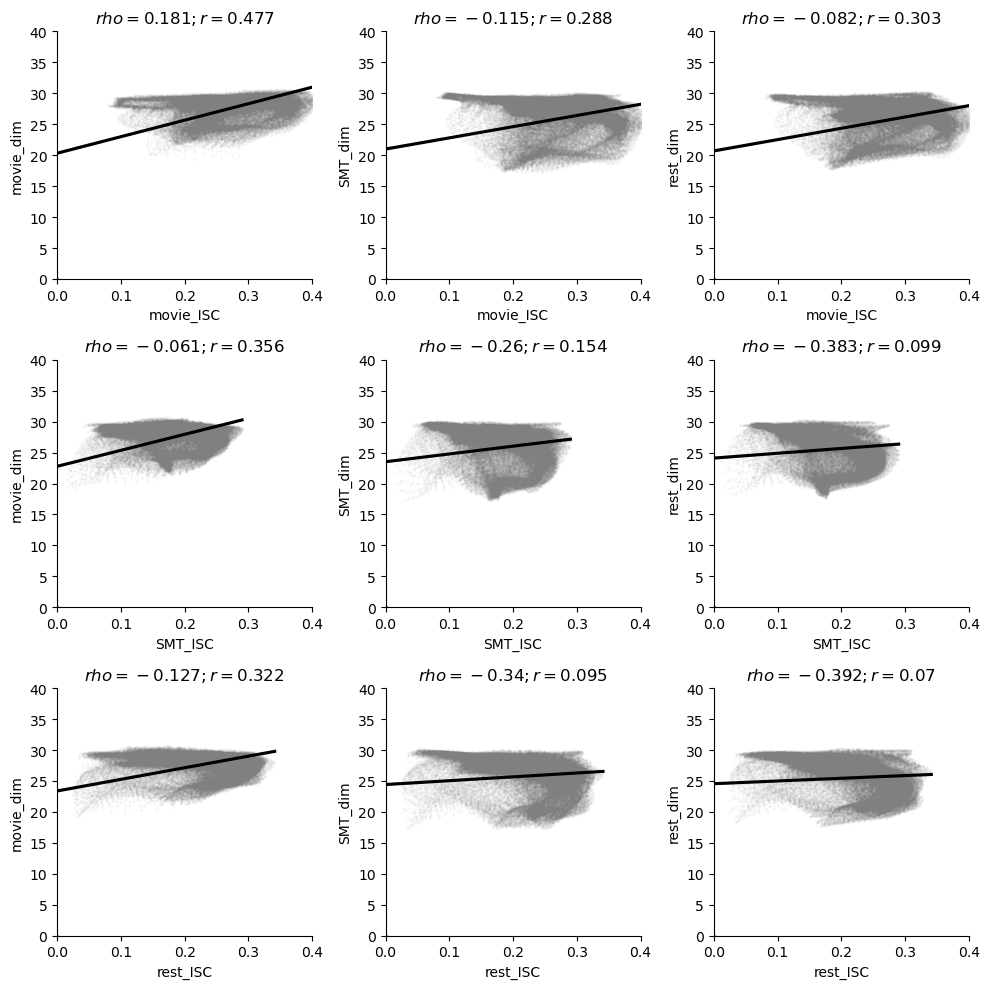

In [28]:
from itertools import permutations
 
# initialize lists
list1={'movie_ISC':np.mean(movie_isc,axis=0), 'SMT_ISC':np.mean(smt_isc,axis=0),'rest_ISC':np.mean(rest_isc,axis=0)}
list2 = {'movie_dim':np.mean(movie_optt,axis=0),'SMT_dim':np.mean(smt_optt,axis=0),'rest_dim':np.mean(rest_optt,axis=0)}
unique_combinations = []
 
for i in range(len(list1.keys())):
    for j in range(len(list2.keys())):
        unique_combinations.append((list(list1.keys())[i], list(list2.keys())[j]))
print(unique_combinations)

fig,ax=plt.subplots(3,3,figsize=(10,10))
ax=ax.ravel()
for i,comb in enumerate(unique_combinations):
    g=sns.regplot(x=list1[comb[0]], y=list2[comb[1]],  color='black', 
              scatter_kws={'alpha':0.1, 's':0.1, "color":'gray'}, ax=ax[i])
    sns.despine()
    rho,p = stats.spearmanr(list1[comb[0]], list2[comb[1]])
    r,p2 = stats.pearsonr(list1[comb[0]], list2[comb[1]])
    
    g.set(title=f'$rho={np.round(rho,3)}; r={np.round(r,3)}$', 
          xlim=[0,0.4], ylim=[0,40], xlabel=comb[0], ylabel=comb[1])
fig.tight_layout()

In [3]:
for t in ['rest','movie','SMT']:
    for tp in ['optt','autocorr']:
        
        fns = sorted(glob.glob(f'{CAMCAN_RESULTS_DIR}/TPHATE_optt/LOSO/*{t}*{tp}*.nii.gz'))
        print(f'found {len(fns)} for {t} {tp}')

        # plot the group average
        temp = np.zeros(mask.shape)
        results_vecs = []
        for i, f in enumerate(fns):
            d = nib.load(f).get_fdata()
            temp = np.add(temp, d)
            vec = d[coords[0][:], coords[1][:], coords[2][:]]
            results_vecs.append(vec)
        temp /= len(fns)
        r = np.array(results_vecs)
        print(r.shape)
        np.save(f'{CAMCAN_RESULTS_DIR}/TPHATE_optt/{t.upper()}_tphate_{tp}_all_subjects_results.npy', r)


        n = Nifti1Image(temp, affine=mask.affine)
        nib.save(n, f'{CAMCAN_RESULTS_DIR}/TPHATE_optt/group_average_{t}_tphate_{tp}_whole_brain_SL_rad5.nii.gz')
        plot_fn = f'CamCAN/plots/group_average_{t}_tphate_{tp}_whole_brain_SL_rad5.png'
        plotting.plot_img_on_surf(n, 
                                  views=['lateral','medial'], 
                                  cmap=cmap, 
                                  inflate=True, 
                                  bg_on_data=False, 
                                          alpha=0.8,
                                  output_file=plot_fn,
                                  darkness=0.8, 
                                  threshold=1, title=f'Camcan {t} {tp}',
                                 )
        plt.close()
        print(plot_fn)

found 117 for rest optt
(117, 86741)
CamCAN/plots/group_average_rest_tphate_optt_whole_brain_SL_rad5.png
found 117 for rest autocorr
(117, 86741)
CamCAN/plots/group_average_rest_tphate_autocorr_whole_brain_SL_rad5.png
found 117 for movie optt
(117, 86741)
CamCAN/plots/group_average_movie_tphate_optt_whole_brain_SL_rad5.png
found 117 for movie autocorr
(117, 86741)
CamCAN/plots/group_average_movie_tphate_autocorr_whole_brain_SL_rad5.png
found 117 for SMT optt
(117, 86741)
CamCAN/plots/group_average_SMT_tphate_optt_whole_brain_SL_rad5.png
found 117 for SMT autocorr
(117, 86741)
CamCAN/plots/group_average_SMT_tphate_autocorr_whole_brain_SL_rad5.png


In [12]:
mask = utils.get_intersect_mask(35)
cmap = utils.get_brain_cmap()
# aggregate results
coords = np.where(mask.get_fdata() == 1)
# start with ISC
for m in ide.METHOD_NAMES:
    for t in CAMCAN_TASKS:
        if t != 'SMT': t = t.lower()
        fns = sorted(glob.glob(f'{CAMCAN_RESULTS_DIR}/IDE/LOSO/*_{t}*_{m}*.nii.gz'))
        print(f'found {len(fns)} for {t} {m}')
        if len(fns) != 117:
            continue
        # plot the group average
        temp = np.zeros(mask.shape)
        results_vecs = []
        for i, f in enumerate(fns):
            d = nib.load(f).get_fdata()
            temp = np.add(temp, d)
            vec = d[coords[0][:], coords[1][:], coords[2][:]]
            results_vecs.append(vec)
        temp /= len(fns)
        r = np.array(results_vecs)
        print(r.shape)
        np.save(f'{CAMCAN_RESULTS_DIR}/TPHATE_optt/{t.upper()}_{m}_all_subjects_results.npy', r)


        n = Nifti1Image(temp, affine=mask.affine)
        nib.save(n, f'{CAMCAN_RESULTS_DIR}/ISC/group_average_{t}_{m}_whole_brain_SL_rad5.nii.gz')
        plot_fn = f'CamCAN/plots/group_average_{t}_{m}_whole_brain_SL_rad5.png'
        plotting.plot_img_on_surf(n, 
                                  views=['lateral','medial'], 
                                  cmap=cmap, 
                                  inflate=True, 
                                  bg_on_data=False, 
                                          alpha=0.8,
                                  output_file=plot_fn,
                                  darkness=0.8, 
                                  threshold=1, title=f'Camcan {t} {m}',
                                 )
        plt.close()
        print(plot_fn)
    

found 117 for movie CorrInt
(117, 86741)
CamCAN/plots/group_average_movie_CorrInt_whole_brain_SL_rad5.png
found 117 for rest CorrInt
(117, 86741)
CamCAN/plots/group_average_rest_CorrInt_whole_brain_SL_rad5.png
found 117 for SMT CorrInt
(117, 86741)
CamCAN/plots/group_average_SMT_CorrInt_whole_brain_SL_rad5.png
found 117 for movie DIFF_MAP_SE
(117, 86741)
CamCAN/plots/group_average_movie_DIFF_MAP_SE_whole_brain_SL_rad5.png
found 117 for rest DIFF_MAP_SE
(117, 86741)
CamCAN/plots/group_average_rest_DIFF_MAP_SE_whole_brain_SL_rad5.png
found 117 for SMT DIFF_MAP_SE
(117, 86741)
CamCAN/plots/group_average_SMT_DIFF_MAP_SE_whole_brain_SL_rad5.png
found 117 for movie FisherS
(117, 86741)
CamCAN/plots/group_average_movie_FisherS_whole_brain_SL_rad5.png
found 117 for rest FisherS
(117, 86741)
CamCAN/plots/group_average_rest_FisherS_whole_brain_SL_rad5.png
found 117 for SMT FisherS
(117, 86741)
CamCAN/plots/group_average_SMT_FisherS_whole_brain_SL_rad5.png
found 117 for movie KNN
(117, 86741)
Cam

In [6]:
# reorganize data

outdir = '/gpfs/milgram/project/casey/elb77/CamCAN/fMRI_organized/'
all_subjects = utils.get_intersecting_subjects(subject_filter=0)

for S in all_subjects:
    s = S.replace('sub-', '')
    dirname = f'{BASE_DIR_CAMCAN}/{CAMCAN_PREPROC_MIDSTR}/{s}/'
    old_fn = glob.glob(os.path.join(dirname, 'Movie', f'*fMR*_{s}*.nii'))[0]
    new_fn = f'{outdir}/movie/{S}_MOVIE.nii'
    shutil.copy(old_fn, new_fn)
    
    old_fn = glob.glob(os.path.join(dirname, 'SMT', f'*fMR*_{s}*.nii'))[0]
    new_fn = f'{outdir}/smt/{S}_SMT.nii'
    shutil.copy(old_fn, new_fn)
    
    old_fn = glob.glob(os.path.join(dirname, 'Rest', f'*fMR*_{s}*.nii'))[0]
    new_fn = f'{outdir}/rest/{S}_REST.nii'
    shutil.copy(old_fn, new_fn)
    print(S)
    
    


sub-CC320621
sub-CC620821
sub-CC320759


KeyboardInterrupt: 

In [17]:
df_movie = pd.read_csv(CAMCAN_PARTICIPANT_FILES['MOVIE'], sep='\t')
print(df_movie.shape, len(df_movie.participant_id.unique()))
df_movie[df_movie['age']<20]

(649, 6) 649


,participant_id,age,hand,gender_text,gender_code,tiv_cubicmm
1,sub-CC110037,18,89.0,MALE,1,1391950
10,sub-CC110182,18,80.0,FEMALE,2,1323662
18,sub-CC120061,19,70.0,MALE,1,1598322
21,sub-CC120123,19,56.0,FEMALE,2,1260867
34,sub-CC120376,18,79.0,FEMALE,2,1236457
35,sub-CC120409,18,100.0,MALE,1,1624266
36,sub-CC120462,18,-80.0,FEMALE,2,1327319
39,sub-CC120550,19,70.0,MALE,1,1471032
47,sub-CC121111,18,90.0,MALE,1,1696915


In [18]:
df_rest = pd.read_csv(CAMCAN_PARTICIPANT_FILES['REST'], sep='\t')
print(df_rest.shape, len(df_rest.participant_id.unique()))
df_rest[df_rest['age']<20]

(652, 6) 652


,participant_id,age,hand,gender_text,gender_code,tiv_cubicmm
1,sub-CC110037,18,89.0,MALE,1,1391950
10,sub-CC110182,18,80.0,FEMALE,2,1323662
18,sub-CC120061,19,70.0,MALE,1,1598322
21,sub-CC120123,19,56.0,FEMALE,2,1260867
34,sub-CC120376,18,79.0,FEMALE,2,1236457
35,sub-CC120409,18,100.0,MALE,1,1624266
36,sub-CC120462,18,-80.0,FEMALE,2,1327319
39,sub-CC120550,19,70.0,MALE,1,1471032
47,sub-CC121111,18,90.0,MALE,1,1696915


In [19]:
df_smt = pd.read_csv(CAMCAN_PARTICIPANT_FILES['SMT'], sep='\t')
print(df_smt.shape, len(df_smt.participant_id.unique()))
df_smt[df_smt['age']<20]

(651, 6) 651


,participant_id,age,hand,gender_text,gender_code,tiv_cubicmm
1,sub-CC110037,18,89.0,MALE,1,1391950
10,sub-CC110182,18,80.0,FEMALE,2,1323662
18,sub-CC120061,19,70.0,MALE,1,1598322
21,sub-CC120123,19,56.0,FEMALE,2,1260867
34,sub-CC120376,18,79.0,FEMALE,2,1236457
35,sub-CC120409,18,100.0,MALE,1,1624266
36,sub-CC120462,18,-80.0,FEMALE,2,1327319
39,sub-CC120550,19,70.0,MALE,1,1471032
47,sub-CC121111,18,90.0,MALE,1,1696915
